# ADMET Profiling with AI — predicting the properties that decide a drug's fate
### Applied to FA19 and the ferulic acid library

Your rule-based panel (Lipinski, Veber, BOILED-Egg) tells you a molecule is *plausibly* developable. It cannot tell you whether FA19 will be **soluble**, **block the hERG channel** (cardiotoxicity), **inhibit CYP enzymes** (drug-drug interactions), or **cross the blood-brain barrier**. Those are *learned* from experimental data — that's what this notebook adds.

**Tool: ADMET-AI** (Swanson et al., *Bioinformatics* 2024). Why this one:
- It is a set of **Chemprop graph neural networks** trained on the **Therapeutics Data Commons (TDC)** ADMET benchmark — the standard, peer-reviewed ADMET datasets, so the models are validated and citable.
- It predicts **~40 ADMET endpoints** at once from just a SMILES.
- For every endpoint it also reports a **percentile vs. approved drugs (DrugBank)** — the single most intuitive way to read a prediction ("FA19 is more soluble than 78% of approved drugs").
- It's free and fully reproducible — important for a portfolio.

> Run this in **Google Colab** (a GPU runtime is fastest). The models are deep-learning and need more disk/RAM than a light sandbox.


## 1 · Install
*Why these:* `admet_ai` pulls in Chemprop + PyTorch (the GNN engine) and RDKit (molecule handling).

In [5]:
!pip -q install admet_ai rdkit 2>/dev/null
print("installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.9/148.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.0/176.0 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 79.1 MB/s eta 0:00:00
installed


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2 · Load the molecules
We score the whole library plus FA19. If you have `data/library.csv` from the screening repo, load it; otherwise the lead is defined inline so the notebook is self-contained.


In [36]:
import pandas as pd
import csv

try:
    # Attempt to read the CSV with no quoting character explicitly
    lib = pd.read_csv("data/library.csv")
    print(f"Loaded {len(lib)} molecules from library.csv")
except FileNotFoundError:
    lib = pd.DataFrame([{"id":"FA19","name":"FA19 lead",
        "smiles":"COc1ccc(C(=O)Oc2ccc(/C=C/C(=O)O)cc2OC)cc1"}])
    print("library.csv not found — scoring FA19 only")
lib.head()

Loaded 24 molecules from library.csv


,id,klass,smiles
0,FA1,Hydrocinnamic acid derivative,O=C(O)CCc1ccc(O)c(OC)c1
1,FA2,Cinnamic acid derivative,OC(=O)/C=C/c1ccc(O)c(O)c1
2,FA3,Cinnamic acid derivative,OC(=O)/C=C/c1ccc(O)c(OC)c1
3,FA4,Cinnamic acid derivative,COC(=O)/C=C/c1ccc(O)c(OC)c1
4,FA5,Cinnamic acid derivative,CCOC(=O)/C=C/c1ccc(O)c(OC)c1


## 3 · Predict
`ADMETModel()` loads all the pretrained TDC models once. `.predict()` accepts a list of SMILES and returns a DataFrame: one row per molecule, one column per endpoint, plus a matching `*_drugbank_approved_percentile` column for each.

*Why a single call for the whole list:* the model batches them efficiently, and you get a tidy table you can rank and plot.


In [37]:
from admet_ai import ADMETModel
model = ADMETModel()
preds = model.predict(smiles=lib["smiles"].tolist())   # DataFrame indexed by SMILES
preds = preds.reset_index().rename(columns={"index":"smiles"})
out = lib.merge(preds, on="smiles", how="left")
print("Predicted endpoints:", [c for c in preds.columns if not c.endswith('percentile')][:60])
out.to_csv("data/admet_predictions.csv", index=False)
print(f"\nSaved data/admet_predictions.csv  ({out.shape[1]} columns)")

model ensembles:   0%|          | 0/2 [00:00<?, ?it/s]INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

Output()

...

Output()

Output()

Output()

model ensembles: 100%|██████████| 2/2 [00:01<00:00,  1.42it/s]


Predicted endpoints: ['smiles', 'molecular_weight', 'logP', 'hydrogen_bond_acceptors', 'hydrogen_bond_donors', 'Lipinski', 'QED', 'stereo_centers', 'tpsa', 'PAINS_alert', 'BRENK_alert', 'NIH_alert', 'AMES', 'BBB_Martins', 'Bioavailability_Ma', 'CYP1A2_Veith', 'CYP2C19_Veith', 'CYP2C9_Substrate_CarbonMangels', 'CYP2C9_Veith', 'CYP2D6_Substrate_CarbonMangels', 'CYP2D6_Veith', 'CYP3A4_Substrate_CarbonMangels', 'CYP3A4_Veith', 'Carcinogens_Lagunin', 'ClinTox', 'DILI', 'HIA_Hou', 'NR-AR-LBD', 'NR-AR', 'NR-AhR', 'NR-Aromatase', 'NR-ER-LBD', 'NR-ER', 'NR-PPAR-gamma', 'PAMPA_NCATS', 'Pgp_Broccatelli', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53', 'Skin_Reaction', 'hERG', 'Caco2_Wang', 'Clearance_Hepatocyte_AZ', 'Clearance_Microsome_AZ', 'Half_Life_Obach', 'HydrationFreeEnergy_FreeSolv', 'LD50_Zhu', 'Lipophilicity_AstraZeneca', 'PPBR_AZ', 'Solubility_AqSolDB', 'VDss_Lombardo']

Saved data/admet_predictions.csv  (107 columns)


In [34]:
import os

# Create the 'data' directory if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')
    print("Created directory: 'data'")

## 4 · Organise the endpoints into the ADMET story
The raw output has dozens of columns. We group them into the five ADMET stages so the table reads like a developability assessment. (We match by keyword and guard each column, so the cell won't break if ADMET-AI's exact names differ by version.)

**How to read each kind of endpoint:**
- **Regression** (a number): `solubility` = logS (higher = more soluble; > -4 is good); `lipophilicity` = logD; `clearance`, `half_life`, `LD50`, `PPBR` (% plasma protein bound), `VDss`.
- **Classification** (a probability 0-1): `hERG`, `AMES`, `DILI`, `CYP..._inhibitor`, `BBB`, `Pgp`, `bioavailability` — closer to 1 = more likely to have that property. For **toxicity/CYP**, *lower is safer*; for **absorption/bioavailability**, *higher is better*.


In [38]:
groups = {
 "Absorption":  ["solubility","Caco2","HIA","Pgp","Bioavailability","Lipophilicity","PAMPA"],
 "Distribution":["BBB","PPBR","VDss"],
 "Metabolism":  ["CYP"],
 "Excretion":   ["Clearance","Half_Life","Half_life"],
 "Toxicity":    ["hERG","AMES","DILI","Carcinog","ClinTox","LD50","Skin","Tox"],
}
def cols_for(keys):
    return [c for c in preds.columns
            if any(k.lower() in c.lower() for k in keys) and not c.endswith("percentile")]
for stage, keys in groups.items():
    cs = cols_for(keys)
    if cs:
        print(f"\n=== {stage} ===")
        print(out[["id"]+cs].round(3).to_string(index=False))


=== Absorption ===
  id  Bioavailability_Ma  HIA_Hou  PAMPA_NCATS  Pgp_Broccatelli  Caco2_Wang  Lipophilicity_AstraZeneca  Solubility_AqSolDB
 FA1               0.853    0.934        0.169            0.004      -4.986                     -0.706              -1.630
 FA2               0.453    0.621        0.062            0.004      -5.467                     -0.728              -2.466
 FA3               0.686    0.809        0.123            0.007      -5.010                     -0.432              -2.823
 FA4               0.843    0.999        0.918            0.038      -4.507                      1.876              -2.891
 FA5               0.813    1.000        0.936            0.070      -4.446                      2.280              -2.844
 FA6               0.792    1.000        0.943            0.135      -4.484                      2.690              -3.314
 FA7               0.751    1.000        0.951            0.227      -4.535                      3.006              -3.

## 5 · The intuitive view — FA19 vs. approved drugs
Raw numbers are hard to judge in isolation. The DrugBank **percentile** answers "is this normal for a real drug?" A bar near 50 means FA19 looks typical; extreme values flag where it stands out (good or bad).


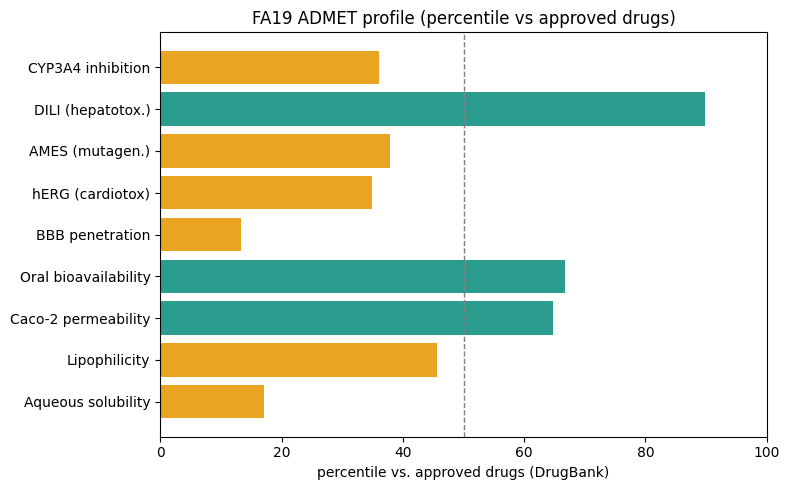


Generating comparison heatmap for the library...


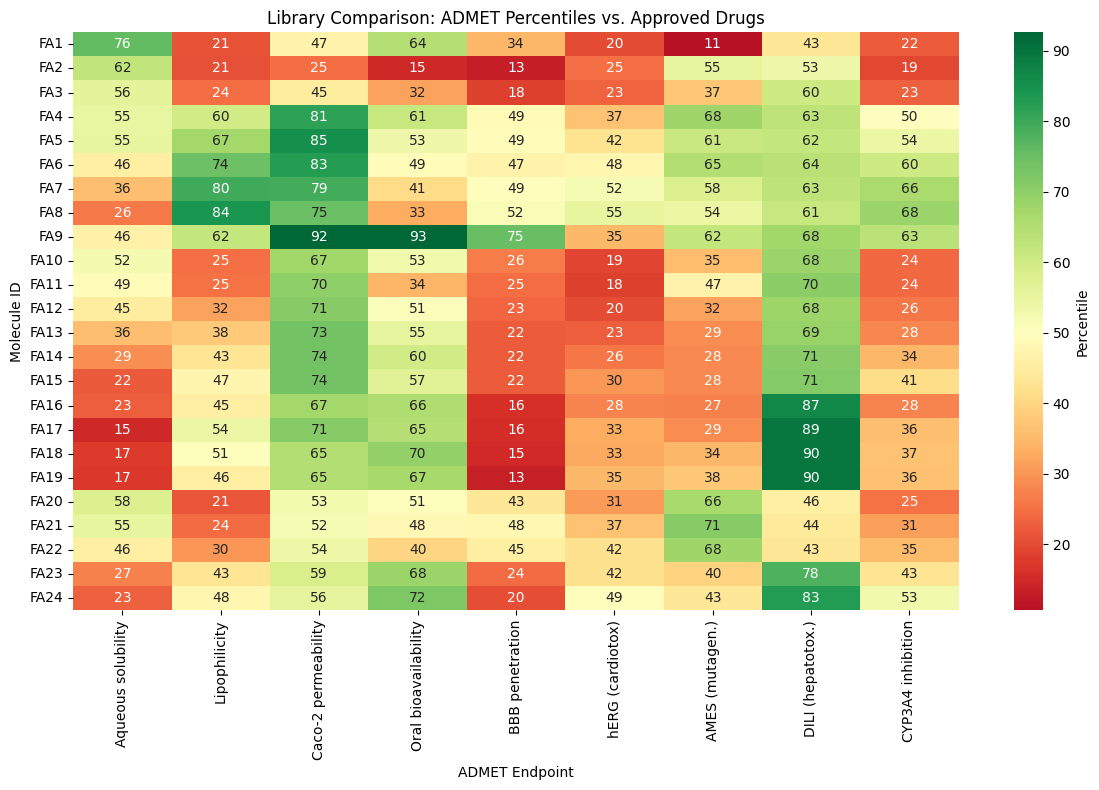

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd

# 1. Individual Profile (Original request context)
# Let's use FA19 as the primary lead for the single plot
lead_id = "FA19"
row = out[out["id"] == lead_id].iloc[0]
key = {
 "Aqueous solubility":"solubility","Lipophilicity":"Lipophilicity","Caco-2 permeability":"Caco2",
 "Oral bioavailability":"Bioavailability","BBB penetration":"BBB","hERG (cardiotox)":"hERG",
 "AMES (mutagen.)":"AMES","DILI (hepatotox.)":"DILI","CYP3A4 inhibition":"CYP3A4",
}

labels, vals = [], []
for lab, frag in key.items():
    hits = [c for c in out.columns if frag.lower() in c.lower() and c.endswith("percentile")]
    if hits:
        labels.append(lab)
        vals.append(float(row[hits[0]]))

plt.figure(figsize=(8,5))
colors = ["#2a9d8f" if v >= 50 else "#e9a522" for v in vals]
plt.barh(labels, vals, color=colors)
plt.axvline(50, color="grey", ls="--", lw=1)
plt.xlabel("percentile vs. approved drugs (DrugBank)")
plt.xlim(0,100)
plt.title(f"{lead_id} ADMET profile (percentile vs approved drugs)")
plt.tight_layout()

os.makedirs('figures', exist_ok=True)
plt.savefig(f"figures/{lead_id.lower()}_admet_profile.png", dpi=150)
plt.show()

# 2. Comparison Heatmap for all molecules
print("\nGenerating comparison heatmap for the library...")

# Prepare data for heatmap: Molecules (rows) vs Endpoints (columns)
heatmap_data = []
for _, r in out.iterrows():
    row_vals = {'ID': r['id']}
    for lab, frag in key.items():
        hits = [c for c in out.columns if frag.lower() in c.lower() and c.endswith("percentile")]
        if hits: row_vals[lab] = float(r[hits[0]])
    heatmap_data.append(row_vals)

df_hm = pd.DataFrame(heatmap_data).set_index('ID')

plt.figure(figsize=(12, 8))
sns.heatmap(df_hm, annot=True, fmt=".0f", cmap="RdYlGn", center=50, cbar_kws={'label': 'Percentile'})
plt.title("Library Comparison: ADMET Percentiles vs. Approved Drugs")
plt.xlabel("ADMET Endpoint")
plt.ylabel("Molecule ID")
plt.tight_layout()

plt.savefig("figures/library_admet_comparison.png", dpi=150)
plt.show()

## 6 · Honest interpretation — what this is and isn't
- **A prediction is a hypothesis, not an assay result.** It tells you where to *look*, e.g. "hERG percentile is high → run a real patch-clamp assay before trusting this."
- **Applicability domain.** These models were trained mostly on drug-like organic molecules; your ferulic esters fit that space, so predictions are reasonable — but a value for an exotic structure would be unreliable.
- **Use it to triage and to tell a story.** In the portfolio: "ADMET-AI predicts FA19 is soluble, non-mutagenic, low CYP3A4 liability, and BBB-impermeant (appropriate for a peripheral COX-2 target) — these are the developability checks beyond Lipinski."

This is the difference between *"passes Lipinski"* and *"profiled across 40 ADMET endpoints against approved-drug benchmarks."* The second is what a medicinal chemist expects to see.
